In [1]:
# TF-IDF + Logistic regression



# Import Required Libraries

import os
import re
import gc
import time
import json
import glob
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, Dataset as TorchDataset

from datasets import Dataset as HFDataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [2]:
# Set Dataset Directory

data_root_dir = Path(r"D:\aclImdb_v1.tar\aclImdb")

In [3]:
# Define Function for Loading Reviews

def load_reviews_from_folder(folder, label):
    texts = []
    labels = []
    
    for file_name in os.listdir(folder):
        file_path = os.path.join(folder, file_name)
        
        if file_name.endswith(".txt"):
            with open(file_path, "r", encoding="utf-8") as f:
                text = f.read()
                
                texts.append(text)
                labels.append(label)
    
    return pd.DataFrame({
        "text": texts,
        "label": labels
    })

In [4]:
# Load and Organize Training and Test Sets

train_pos = load_reviews_from_folder(data_root_dir / "train" / "pos", 1)
train_neg = load_reviews_from_folder(data_root_dir / "train" / "neg", 0)
test_pos = load_reviews_from_folder(data_root_dir / "test" / "pos", 1)
test_neg = load_reviews_from_folder(data_root_dir / "test" / "neg", 0)

train_dataset = pd.concat([train_pos, train_neg], ignore_index=True)
test_dataset = pd.concat([test_pos, test_neg], ignore_index=True)

In [5]:
# Basic EDA: Check Dataset Size and Label Distribution

print("Train shape:", train_dataset.shape)
print("Test shape:", test_dataset.shape)

print("\nTrain label distribution:")
print(train_dataset["label"].value_counts())

print("\nTest label distribution:")
print(test_dataset["label"].value_counts())

Train shape: (25000, 2)
Test shape: (25000, 2)

Train label distribution:
label
1    12500
0    12500
Name: count, dtype: int64

Test label distribution:
label
1    12500
0    12500
Name: count, dtype: int64


In [6]:
# Basic EDA: Inspect Sample Reviews

print("Train sample 1:")
print(train_dataset["text"].iloc[0])
print("\nLabel:", train_dataset["label"].iloc[0])

print("\n" + "="*100 + "\n")

print("Train sample 2:")
print(train_dataset["text"].iloc[12500])
print("\nLabel:", train_dataset["label"].iloc[12500])

Train sample 1:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!

Label: 1


Train sample 2:
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra 

In [7]:
# Basic EDA: Analyze Review Length

train_dataset["text_length"] = train_dataset["text"].apply(len)
test_dataset["text_length"] = test_dataset["text"].apply(len)

print(train_dataset["text_length"].describe())
print()
print(test_dataset["text_length"].describe())

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: text_length, dtype: float64

count    25000.00000
mean      1293.79240
std        975.90776
min         32.00000
25%        696.00000
50%        962.00000
75%       1572.00000
max      12988.00000
Name: text_length, dtype: float64


In [8]:
# Basic EDA: Check Missing Values and Duplicates

print("Train missing values:")
print(train_dataset.isnull().sum())

print("\nTest missing values:")
print(test_dataset.isnull().sum())

print("\nTrain duplicated texts:", train_dataset["text"].duplicated().sum())
print("Test duplicated texts:", test_dataset["text"].duplicated().sum())

Train missing values:
text           0
label          0
text_length    0
dtype: int64

Test missing values:
text           0
label          0
text_length    0
dtype: int64

Train duplicated texts: 96
Test duplicated texts: 199


In [9]:
# Basic EDA: Check HTML Line Break Tags

print("Train texts containing <br />:", train_dataset["text"].str.contains("<br", regex=False).sum())
print("Test texts containing <br />:", test_dataset["text"].str.contains("<br", regex=False).sum())

Train texts containing <br />: 14665
Test texts containing <br />: 14535


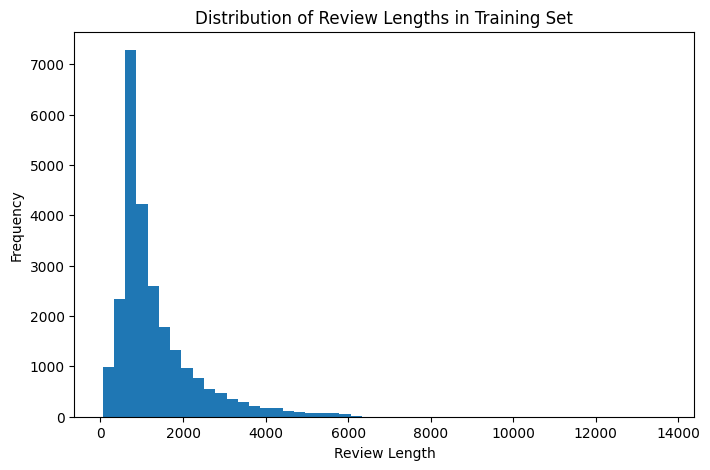

In [10]:
# Basic EDA: Visualize Review Length Distribution
plt.figure(figsize=(8,5))
plt.hist(train_dataset["text_length"], bins=50)
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Distribution of Review Lengths in Training Set")
plt.show()

In [11]:
# Create Cleaned Text for Traditional Models

def clean_text_basic(text):
    text = text.lower()                          # Make everything lowercase
    text = re.sub(r"<br\s*/?>", " ", text)       # Remove the common HTML line break tags
    text = re.sub(r"[^a-zA-Z\s]", " ", text)     # Remove non-alphabetic characters
    text = re.sub(r"\s+", " ", text).strip()     # Change multiple spaces into one
    return text

train_dataset["clean_text"] = train_dataset["text"].apply(clean_text_basic)
test_dataset["clean_text"] = test_dataset["text"].apply(clean_text_basic)

print(train_dataset[["text", "clean_text", "label"]].head())
print(train_dataset.shape)
print(test_dataset.shape)

                                                text  \
0  Bromwell High is a cartoon comedy. It ran at t...   
1  Homelessness (or Houselessness as George Carli...   
2  Brilliant over-acting by Lesley Ann Warren. Be...   
3  This is easily the most underrated film inn th...   
4  This is not the typical Mel Brooks film. It wa...   

                                          clean_text  label  
0  bromwell high is a cartoon comedy it ran at th...      1  
1  homelessness or houselessness as george carlin...      1  
2  brilliant over acting by lesley ann warren bes...      1  
3  this is easily the most underrated film inn th...      1  
4  this is not the typical mel brooks film it was...      1  
(25000, 4)
(25000, 4)


In [12]:
# Prepare data
# Only keep the columns needed for this baseline to avoid interference.

train_df = train_dataset[["clean_text", "label"]].copy()
test_df = test_dataset[["clean_text", "label"]].copy()

# Extract the input and the label
X_train = train_df["clean_text"]
y_train = train_df["label"]

X_test = test_df["clean_text"]
y_test = test_df["label"]

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nLabel distribution in training set:")
print(y_train.value_counts())


Training samples: 25000
Testing samples: 25000

Label distribution in training set:
label
1    12500
0    12500
Name: count, dtype: int64


In [13]:
# Build baseline pipeline
# clean_text -> TF-IDF vectors -> Logistic Regression classifier

baseline_pipeline = Pipeline([
    
    # Step 1: Convert the text into TF-IDF feature vectors
    ("tfidf", TfidfVectorizer(
        lowercase=True,        # Uniformly convert to lowercase and reduce repetitive features
        stop_words="english",  # Remove common English stop words to reduce noise
        max_features=20000,    # Limit the maximum number of features, control the dimension and the training cost
        ngram_range=(1, 2),    # Use both unigram and bigram simultaneously
        min_df=2,              # Only words that appear in at least 2 documents will be retained
        max_df=0.95            # Words that are overly common (appearing in 95% of the documents) are ignored
    )),
    
    # Step 2: Perform binary classification using Logistic Regression
    ("clf", LogisticRegression(
        max_iter=1000,         # Increase the maximum number of iterations and reduce the risk of non-convergence
        random_state=42        # Fix the random seed to ensure reproducibility of the results
    ))
])

baseline_pipeline

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [14]:
# Train the baseline model

start_train = time.time()
baseline_pipeline.fit(X_train, y_train)
end_train = time.time()
train_time = end_train - start_train

print(f"Training time: {train_time:.2f} seconds")

Training time: 10.94 seconds


In [15]:
# Make predictions on the test set

start_pred = time.time()
y_pred = baseline_pipeline.predict(X_test)
end_pred = time.time()
inference_time = end_pred - start_pred

print(f"Inference time on test set: {inference_time:.2f} seconds")

Inference time on test set: 4.70 seconds


In [16]:
# Evaluate model performance

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print classification report

print("Classification Report: TF-IDF + Logistic Regression\n")
print(classification_report(y_test, y_pred, digits=4))

Classification Report: TF-IDF + Logistic Regression

              precision    recall  f1-score   support

           0     0.8858    0.8790    0.8824     12500
           1     0.8800    0.8866    0.8833     12500

    accuracy                         0.8828     25000
   macro avg     0.8829    0.8828    0.8828     25000
weighted avg     0.8829    0.8828    0.8828     25000



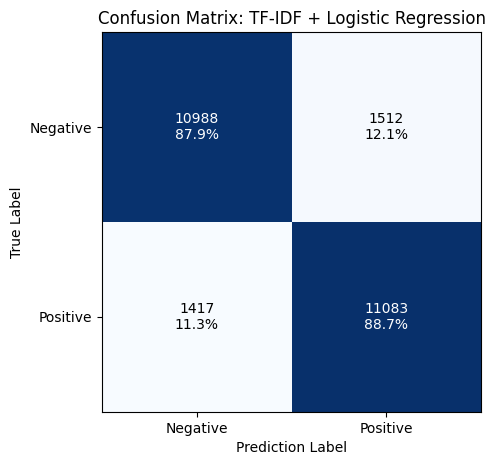

In [17]:
# Plot confusion matrix (count + percentage)

cm = confusion_matrix(y_test, y_pred)
cm_percent = cm / cm.sum(axis=1, keepdims=True)

labels = ["Negative", "Positive"]

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cm_percent, cmap="Blues")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Prediction Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix: TF-IDF + Logistic Regression")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            f"{cm[i, j]}\n{cm_percent[i, j]*100:.1f}%",
            ha="center", va="center",
            color="white" if cm_percent[i, j] > 0.5 else "black"
        )

plt.tight_layout()
plt.show()

In [18]:
# Save results into a table

results_df = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Train Time (s)": train_time,
        "   Inference Time (s)": inference_time
    }
])

results_df

,Model,Accuracy,Precision,Recall,F1,Train Time (s),Inference Time (s)
0,TF-IDF + Logistic Regression,0.88284,0.879952,0.88664,0.883284,10.939541,4.700473


In [19]:
# DistilBERT




# 1. Check device
# Confirm if GPU is available

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [20]:
# 2. Prepare data
# DistilBERT uses the original "text" column

train_df = train_dataset[["text", "label"]].copy()
test_df = test_dataset[["text", "label"]].copy()

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))
print("\nTraining label distribution:")
print(train_df["label"].value_counts())

Training samples: 25000
Testing samples: 25000

Training label distribution:
label
1    12500
0    12500
Name: count, dtype: int64


In [21]:
# 3. Convert pandas DataFrame to Dataset

train_hf = HFDataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
test_hf = HFDataset.from_pandas(test_df.reset_index(drop=True), preserve_index=False)

In [22]:
# 4. Load tokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [23]:
# 5. Convert the original text into token ids that are readable by the model

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tokenized = train_hf.map(tokenize_function, batched=True)
test_tokenized = test_hf.map(tokenize_function, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [24]:
# 6. Select columns in Dataset to feed the model

train_tokenized = train_tokenized.remove_columns(
    [col for col in train_tokenized.column_names if col not in ["input_ids", "attention_mask", "label"]]
)
test_tokenized = test_tokenized.remove_columns(
    [col for col in test_tokenized.column_names if col not in ["input_ids", "attention_mask", "label"]]
)

train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

In [25]:
# 7. Load DistilBERT model

id2label = {0: 'negative', 1: 'positive'} 
label2id = {'negative': 0, 'positive': 1} 

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
# 8. Define evaluation metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    accuracy = accuracy_score(labels, preds)
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [27]:
# 9. Set training arguments
# Configure the number of training epochs, batch size, as well as the saving and evaluation strategies

training_args = TrainingArguments(
    output_dir="./distilbert_imdb_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

In [28]:
# 10. Create Trainer, integrate the model, parameters, dataset and evaluation function together

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [29]:
# 11. Begin fine-tuning

start_train = time.time()
trainer.train()
end_train = time.time()
distilbert_train_time = end_train - start_train

print(f"\nTraining time: {distilbert_train_time:.2f} seconds")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.289547,0.227077,0.910880,0.907619,0.914880,0.911235
2,0.166440,0.267329,0.912720,0.903614,0.924000,0.913694


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training time: 1820.84 seconds


In [30]:
# 12. Output Accuracy / Precision / Recall / F1

start_pred = time.time()
pred_output = trainer.predict(test_tokenized)
end_pred = time.time()
distilbert_inference_time = end_pred - start_pred

print(f"Inference time on test set: {distilbert_inference_time:.2f} seconds")

pred_output.metrics
y_pred_distilbert = np.argmax(pred_output.predictions, axis=1)
y_true_distilbert = pred_output.label_ids

Inference time on test set: 221.56 seconds


In [31]:
# 13. Summarize DistilBERT results

distilbert_accuracy = pred_output.metrics["test_accuracy"]
distilbert_precision = pred_output.metrics["test_precision"]
distilbert_recall = pred_output.metrics["test_recall"]
distilbert_f1 = pred_output.metrics["test_f1"]

distilbert_results_df = pd.DataFrame([
    {
        "Model": "DistilBERT",
        "Accuracy": distilbert_accuracy,
        "Precision": distilbert_precision,
        "Recall": distilbert_recall,
        "F1": distilbert_f1,
        "Train Time (s)": distilbert_train_time,
        "Inference Time (s)": distilbert_inference_time
    }
])

distilbert_results_df

,Model,Accuracy,Precision,Recall,F1,Train Time (s),Inference Time (s)
0,DistilBERT,0.91272,0.903614,0.924,0.913694,1820.844212,221.55577


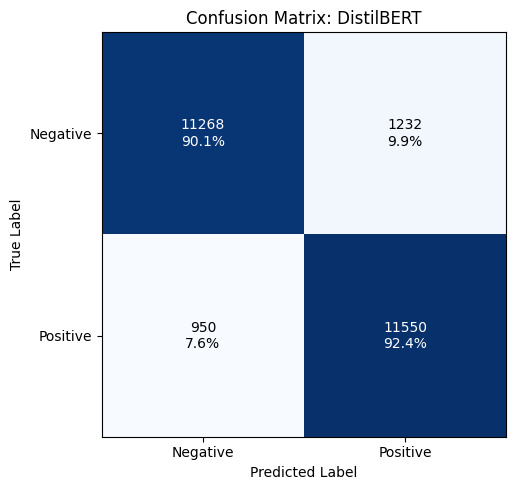

In [32]:
# 14. Plot confusion matrix

cm = confusion_matrix(y_true_distilbert, y_pred_distilbert)
cm_percent = cm / cm.sum(axis=1, keepdims=True)

labels = ["Negative", "Positive"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm_percent, cmap="Blues")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix: DistilBERT")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            f"{cm[i, j]}\n{cm_percent[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="white" if cm_percent[i, j] > 0.5 else "black"
        )

plt.tight_layout()
plt.show()

In [33]:
# 15. Compare baseline and DistilBERT

comparison_df = pd.concat([results_df, distilbert_results_df], ignore_index=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1,Train Time (s),Inference Time (s),Inference Time (s)
0,TF-IDF + Logistic Regression,0.88284,0.879952,0.88664,0.883284,10.939541,4.700473,NaN
1,DistilBERT,0.91272,0.903614,0.92400,0.913694,1820.844212,NaN,221.55577


In [34]:
# 16. Export results

comparison_df.to_csv("final_results_three_models.csv", index=False)

print("Saved: final_results_three_models.csv")

Saved: final_results_three_models.csv


In [35]:
# Naive Bayes

# 1. Vectorize text data using TF-IDF
nb_start_time = time.time()

vectorizer = TfidfVectorizer(max_features=5000)

# 2. Vectorize the training data and test data
X_train = vectorizer.fit_transform(train_dataset["text"])
X_test = vectorizer.transform(test_dataset["text"])

# 3. Initialize the Naive Bayes model
nb_model = MultinomialNB()

# 4. Train the Naive Bayes model
nb_model.fit(X_train, train_dataset["label"])

nb_train_time = time.time() - nb_start_time

# 5. Predict test set
nb_inference_start_time = time.time()

nb_y_pred = nb_model.predict(X_test)

nb_inference_time = time.time() - nb_inference_start_time

# 6. Calculate evaluation indicators
nb_accuracy = accuracy_score(test_dataset["label"], nb_y_pred)
nb_precision = precision_score(test_dataset["label"], nb_y_pred)
nb_recall = recall_score(test_dataset["label"], nb_y_pred)
nb_f1 = f1_score(test_dataset["label"], nb_y_pred)

# 7. Save results into a table
nb_results_df = pd.DataFrame([
    {
        "Model": "Naive Bayes",
        "Accuracy": nb_accuracy,
        "Precision": nb_precision,
        "Recall": nb_recall,
        "F1": nb_f1,
        "Train Time (s)": nb_train_time,
        "Inference Time (s)": nb_inference_time
    }
])

nb_results_df

,Model,Accuracy,Precision,Recall,F1,Train Time (s),Inference Time (s)
0,Naive Bayes,0.84052,0.854738,0.82048,0.837259,7.37228,0.01452


In [36]:
# Further Work: Data-size Experiments
# Compare Naive Bayes, Logistic Regression, and DistilBERT under different training data sizes.

test_traditional_df = test_dataset[["clean_text", "label"]].copy()
test_distilbert_df = test_dataset[["text", "label"]].copy()

X_test_traditional = test_traditional_df["clean_text"]
y_test = test_traditional_df["label"]

print("Test samples:", len(test_dataset))
print("\nTest label distribution:")
print(y_test.value_counts())

Test samples: 25000

Test label distribution:
label
1    12500
0    12500
Name: count, dtype: int64


In [37]:
# Create balanced training subsets for data-size experiments

def create_balanced_train_subset(train_dataset, ratio, random_state=42):
    if ratio == 1.0:
        subset_df = train_dataset.copy()
        subset_df = subset_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
        return subset_df
    
    positive_df = train_dataset[train_dataset["label"] == 1]
    negative_df = train_dataset[train_dataset["label"] == 0]
    
    n_pos = int(len(positive_df) * ratio)
    n_neg = int(len(negative_df) * ratio)
    
    positive_subset = positive_df.sample(n=n_pos, random_state=random_state)
    negative_subset = negative_df.sample(n=n_neg, random_state=random_state)
    
    subset_df = pd.concat([positive_subset, negative_subset], ignore_index=True)
    subset_df = subset_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return subset_df


data_ratios = [0.2, 0.5, 1.0]

for ratio in data_ratios:
    subset_df = create_balanced_train_subset(train_dataset, ratio)
    print(f"\nTraining ratio: {int(ratio * 100)}%")
    print("Subset shape:", subset_df.shape)
    print(subset_df["label"].value_counts())


Training ratio: 20%
Subset shape: (5000, 4)
label
1    2500
0    2500
Name: count, dtype: int64

Training ratio: 50%
Subset shape: (12500, 4)
label
1    6250
0    6250
Name: count, dtype: int64

Training ratio: 100%
Subset shape: (25000, 4)
label
1    12500
0    12500
Name: count, dtype: int64


In [38]:
# Define evaluation function

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return accuracy, precision, recall, f1

In [39]:
# Data-size experiments for traditional models:
# 1. TF-IDF + Naive Bayes
# 2. TF-IDF + Logistic Regression

traditional_results = []

for ratio in data_ratios:
    
    train_subset = create_balanced_train_subset(train_dataset, ratio)
    
    train_traditional_df = train_subset[["clean_text", "label"]].copy()
    
    X_train_subset = train_traditional_df["clean_text"]
    y_train_subset = train_traditional_df["label"]
    
    traditional_models = {
        "TF-IDF + Naive Bayes": Pipeline([
            ("tfidf", TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95
            )),
            ("clf", MultinomialNB())
        ]),
        
        "TF-IDF + Logistic Regression": Pipeline([
            ("tfidf", TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95
            )),
            ("clf", LogisticRegression(
                max_iter=1000,
                random_state=42
            ))
        ])
    }
    
    for model_name, model_pipeline in traditional_models.items():
                
        start_train = time.time()
        model_pipeline.fit(X_train_subset, y_train_subset)
        end_train = time.time()
        train_time = end_train - start_train
        
        start_pred = time.time()
        y_pred = model_pipeline.predict(X_test_traditional)
        end_pred = time.time()
        inference_time = end_pred - start_pred
        
        accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred)
        
        traditional_results.append({
            "Training Data Ratio": f"{int(ratio * 100)}%",
            "Training Data Size": len(train_subset),
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Train Time (s)": train_time,
            "Inference Time (s)": inference_time
        })


traditional_results_df = pd.DataFrame(traditional_results)

traditional_results_df

,Training Data Ratio,Training Data Size,Model,Accuracy,Precision,Recall,F1,Train Time (s),Inference Time (s)
0,20%,5000,TF-IDF + Naive Bayes,0.83612,0.860613,0.80216,0.830359,2.265759,4.655697
1,20%,5000,TF-IDF + Logistic Regression,0.85512,0.844803,0.87008,0.857255,2.322377,4.645489
2,50%,12500,TF-IDF + Naive Bayes,0.84488,0.863123,0.81976,0.840883,5.536825,4.290586
3,50%,12500,TF-IDF + Logistic Regression,0.87096,0.864372,0.88000,0.872116,5.082063,4.281756
4,100%,25000,TF-IDF + Naive Bayes,0.84984,0.864842,0.82928,0.846688,9.649062,4.096136
5,100%,25000,TF-IDF + Logistic Regression,0.88284,0.879952,0.88664,0.883284,10.305945,4.292568


In [40]:
# DistilBERT settings for data-size experiments

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

id2label = {0: "negative", 1: "positive"}
label2id = {"negative": 0, "positive": 1}

Device: cuda


In [41]:
# Convert fixed test set to Hugging Face Dataset and tokenize once

test_hf = HFDataset.from_pandas(test_distilbert_df.reset_index(drop=True))

test_tokenized = test_hf.map(tokenize_function, batched=True)

test_tokenized = test_tokenized.remove_columns(
    [col for col in test_tokenized.column_names if col not in ["input_ids", "attention_mask", "label"]]
)

test_tokenized.set_format("torch")
print(test_tokenized)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 25000
})


In [42]:
# Data-size experiments for DistilBERT

distilbert_results = []

for ratio in data_ratios:
    
    print("\n" + "="*80)
    print(f"Fine-tuning DistilBERT with {int(ratio * 100)}% training data")
    print("="*80)
    
    train_subset = create_balanced_train_subset(train_dataset, ratio)
    train_distilbert_df = train_subset[["text", "label"]].copy()
    
    train_hf = HFDataset.from_pandas(train_distilbert_df.reset_index(drop=True))
    
    train_tokenized = train_hf.map(tokenize_function, batched=True)
    
    train_tokenized = train_tokenized.remove_columns(
        [col for col in train_tokenized.column_names if col not in ["input_ids", "attention_mask", "label"]]
    )
    
    train_tokenized.set_format("torch")
    
    # Re-initialize DistilBERT model for each training ratio
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=2,
        id2label=id2label,
        label2id=label2id
    )
    
    model.to(device)
    
    output_dir = f"./distilbert_data_size_{int(ratio * 100)}"
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none"
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=test_tokenized,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )
    
    start_train = time.time()
    trainer.train()
    end_train = time.time()
    train_time = end_train - start_train
    
    start_pred = time.time()
    pred_output = trainer.predict(test_tokenized)
    end_pred = time.time()
    inference_time = end_pred - start_pred
    
    accuracy = pred_output.metrics["test_accuracy"]
    precision = pred_output.metrics["test_precision"]
    recall = pred_output.metrics["test_recall"]
    f1 = pred_output.metrics["test_f1"]
    
    distilbert_results.append({
        "Training Data Ratio": f"{int(ratio * 100)}%",
        "Training Data Size": len(train_subset),
        "Model": "DistilBERT",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Train Time (s)": train_time,
        "Inference Time (s)": inference_time
    })
    
    print(f"\nDistilBERT Results with {int(ratio * 100)}% training data")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"Train Time: {train_time:.2f} seconds")
    print(f"Inference Time: {inference_time:.2f} seconds")
    
    # Clean memory after each ratio
    del model
    del trainer
    del train_hf
    del train_tokenized
    
    gc.collect()
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Fine-tuning DistilBERT with 20% training data


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.390118,0.266311,0.890520,0.889678,0.891600,0.890638
2,0.202673,0.303488,0.894760,0.877804,0.917200,0.897070


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DistilBERT Results with 20% training data
Accuracy: 0.8948
Precision: 0.8778
Recall: 0.9172
F1: 0.8971
Train Time: 715.90 seconds
Inference Time: 220.16 seconds

Fine-tuning DistilBERT with 50% training data


Map:   0%|          | 0/12500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.321297,0.254579,0.896440,0.865369,0.938960,0.900664
2,0.182136,0.287659,0.905320,0.904899,0.905840,0.905369


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DistilBERT Results with 50% training data
Accuracy: 0.9053
Precision: 0.9049
Recall: 0.9058
F1: 0.9054
Train Time: 1129.43 seconds
Inference Time: 222.12 seconds

Fine-tuning DistilBERT with 100% training data


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.293948,0.239044,0.908520,0.893929,0.927040,0.910183
2,0.172608,0.261321,0.913720,0.906341,0.922800,0.914496


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DistilBERT Results with 100% training data
Accuracy: 0.9137
Precision: 0.9063
Recall: 0.9228
F1: 0.9145
Train Time: 1810.68 seconds
Inference Time: 219.14 seconds


In [43]:
distilbert_data_size_results_df = pd.DataFrame(distilbert_results)

distilbert_data_size_results_df

,Training Data Ratio,Training Data Size,Model,Accuracy,Precision,Recall,F1,Train Time (s),Inference Time (s)
0,20%,5000,DistilBERT,0.89476,0.877804,0.91720,0.897070,715.901012,220.164963
1,50%,12500,DistilBERT,0.90532,0.904899,0.90584,0.905369,1129.434779,222.123236
2,100%,25000,DistilBERT,0.91372,0.906341,0.92280,0.914496,1810.676478,219.141574


In [44]:
# Combine traditional model results and DistilBERT results

data_size_results_df = pd.concat(
    [traditional_results_df,distilbert_data_size_results_df],
    ignore_index=True
)

# Sort results for easier reading

ratio_order = {
    "20%": 1,"50%": 2,"100%": 3
}

model_order = {
    "TF-IDF + Naive Bayes": 1,
    "TF-IDF + Logistic Regression": 2,
    "DistilBERT": 3
}

data_size_results_df["Ratio Order"] = data_size_results_df["Training Data Ratio"].map(ratio_order)
data_size_results_df["Model Order"] = data_size_results_df["Model"].map(model_order)

data_size_results_df = data_size_results_df.sort_values(
    by=["Ratio Order", "Model Order"]
).drop(columns=["Ratio Order", "Model Order"]).reset_index(drop=True)

data_size_results_df

,Training Data Ratio,Training Data Size,Model,Accuracy,Precision,Recall,F1,Train Time (s),Inference Time (s)
0,20%,5000,TF-IDF + Naive Bayes,0.83612,0.860613,0.80216,0.830359,2.265759,4.655697
1,20%,5000,TF-IDF + Logistic Regression,0.85512,0.844803,0.87008,0.857255,2.322377,4.645489
2,20%,5000,DistilBERT,0.89476,0.877804,0.91720,0.897070,715.901012,220.164963
3,50%,12500,TF-IDF + Naive Bayes,0.84488,0.863123,0.81976,0.840883,5.536825,4.290586
4,50%,12500,TF-IDF + Logistic Regression,0.87096,0.864372,0.88000,0.872116,5.082063,4.281756
5,50%,12500,DistilBERT,0.90532,0.904899,0.90584,0.905369,1129.434779,222.123236
6,100%,25000,TF-IDF + Naive Bayes,0.84984,0.864842,0.82928,0.846688,9.649062,4.096136
7,100%,25000,TF-IDF + Logistic Regression,0.88284,0.879952,0.88664,0.883284,10.305945,4.292568
8,100%,25000,DistilBERT,0.91372,0.906341,0.92280,0.914496,1810.676478,219.141574


In [45]:
data_size_results_df.to_csv("Data_size_experiment_all_models.csv", index=False)

print("Saved: Data_size_experiment_all_models.csv")

Saved: Data_size_experiment_all_models.csv


In [46]:
# Create F1 comparison table

f1_comparison_table = data_size_results_df.pivot(
    index="Training Data Ratio",
    columns="Model",
    values="F1"
)

f1_comparison_table = f1_comparison_table.loc[["20%", "50%", "100%"]]

f1_comparison_table

Model,DistilBERT,TF-IDF + Logistic Regression,TF-IDF + Naive Bayes
Training Data Ratio,,,
20%,0.897070,0.857255,0.830359
50%,0.905369,0.872116,0.840883
100%,0.914496,0.883284,0.846688


In [47]:
f1_comparison_table.to_csv("Data_size_experiment_f1_comparison_table.csv")

print("Saved: Data_size_experiment_f1_comparison_table.csv")

Saved: Data_size_experiment_f1_comparison_table.csv


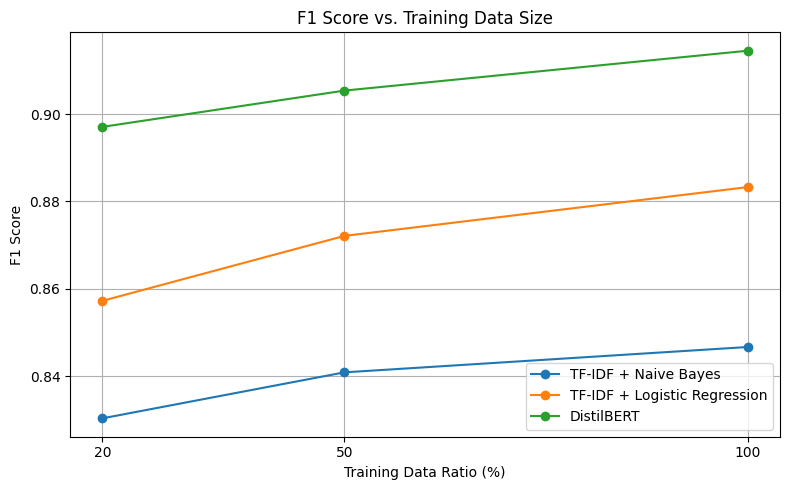

In [48]:
# Plot F1 score across different training data sizes

plot_df = data_size_results_df.copy()
plot_df["Training Data Ratio Numeric"] = plot_df["Training Data Ratio"].str.replace("%", "").astype(int)

plt.figure(figsize=(8, 5))

for model_name in plot_df["Model"].unique():
    model_df = plot_df[plot_df["Model"] == model_name]
    
    plt.plot(
        model_df["Training Data Ratio Numeric"],
        model_df["F1"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training Data Ratio (%)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Training Data Size")
plt.xticks([20, 50, 100])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

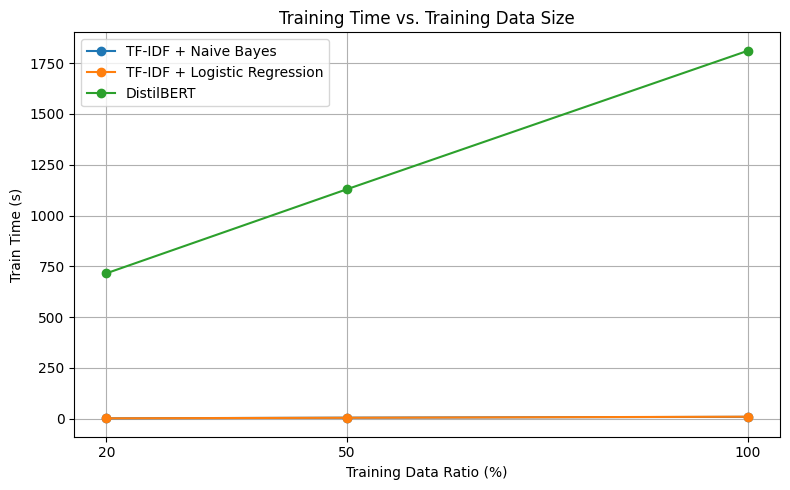

Saved: Data_size_experiment_training_time_line_chart.png


In [49]:
# Plot training time across different training data sizes

plt.figure(figsize=(8, 5))

for model_name in plot_df["Model"].unique():
    model_df = plot_df[plot_df["Model"] == model_name]
    
    plt.plot(
        model_df["Training Data Ratio Numeric"],
        model_df["Train Time (s)"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training Data Ratio (%)")
plt.ylabel("Train Time (s)")
plt.title("Training Time vs. Training Data Size")
plt.xticks([20, 50, 100])
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("Data_size_experiment_training_time_line_chart.png", dpi=300)
plt.show()

print("Saved: Data_size_experiment_training_time_line_chart.png")

In [50]:
# Further work: Qualitative Error Analysis
# Analyze typical misclassified reviews across Naive Bayes, Logistic Regression, and DistilBERT.




# Prepare data for qualitative error analysis

train_traditional_df = train_dataset[["clean_text", "label"]].copy()
test_traditional_df = test_dataset[["clean_text", "label"]].copy()

train_distilbert_df = train_dataset[["text", "label"]].copy()
test_distilbert_df = test_dataset[["text", "label"]].copy()

X_train = train_traditional_df["clean_text"]
y_train = train_traditional_df["label"]

X_test = test_traditional_df["clean_text"]
y_test = test_traditional_df["label"]

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

print("\nTest label distribution:")
print(y_test.value_counts())

Training samples: 25000
Testing samples: 25000

Test label distribution:
label
1    12500
0    12500
Name: count, dtype: int64


In [51]:
# Train and predict full-data traditional models for error analysis

nb_pipeline_error_analysis = Pipeline([
    
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    
    ("clf", MultinomialNB())
])
logreg_pipeline_error_analysis = Pipeline([
    
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


print("Training Naive Bayes...")
start_train = time.time()
nb_pipeline_error_analysis.fit(X_train, y_train)
nb_train_time_error = time.time() - start_train
print(f"Naive Bayes training time: {nb_train_time_error:.2f} seconds")


print("\nTraining Logistic Regression...")
start_train = time.time()
logreg_pipeline_error_analysis.fit(X_train, y_train)
logreg_train_time_error = time.time() - start_train
print(f"Logistic Regression training time: {logreg_train_time_error:.2f} seconds")


# Generate predictions from traditional models

y_pred_nb = nb_pipeline_error_analysis.predict(X_test)
y_pred_logreg = logreg_pipeline_error_analysis.predict(X_test)

print("\nNaive Bayes predictions:", len(y_pred_nb))
print("\nLogistic Regression predictions:", len(y_pred_logreg))

Training Naive Bayes...
Naive Bayes training time: 10.26 seconds

Training Logistic Regression...
Logistic Regression training time: 9.97 seconds

Naive Bayes predictions: 25000

Logistic Regression predictions: 25000


In [52]:
# Load saved DistilBERT checkpoint from the 100% data-size experiment

model_checkpoint = "distilbert-base-uncased"
distilbert_output_dir = "./distilbert_data_size_100"

def find_best_or_latest_checkpoint(output_dir):
    
    trainer_state_path = os.path.join(output_dir, "trainer_state.json")
    
    if os.path.exists(trainer_state_path):
        with open(trainer_state_path, "r") as f:
            trainer_state = json.load(f)
        
        best_checkpoint = trainer_state.get("best_model_checkpoint", None)
        
        if best_checkpoint is not None and os.path.exists(best_checkpoint):
            return best_checkpoint
    
    checkpoint_list = glob.glob(os.path.join(output_dir, "checkpoint-*"))
    
    if len(checkpoint_list) == 0:
        raise FileNotFoundError(
            f"No checkpoint found in {output_dir}. "
            "Please check whether the 100% DistilBERT data-size experiment was completed and saved."
        )
    
    checkpoint_list = sorted(
        checkpoint_list,
        key=lambda x: int(x.split("-")[-1])
    )
    
    return checkpoint_list[-1]

best_distilbert_checkpoint = find_best_or_latest_checkpoint(distilbert_output_dir)

print("Using DistilBERT checkpoint:")
print(best_distilbert_checkpoint)




# Prepare DistilBERT test dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(best_distilbert_checkpoint)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

test_hf_error = HFDataset.from_pandas(test_distilbert_df.reset_index(drop=True))

test_tokenized_error = test_hf_error.map(tokenize_function, batched=True)

test_tokenized_error = test_tokenized_error.remove_columns(
    [col for col in test_tokenized_error.column_names if col not in ["input_ids", "attention_mask", "label"]]
)

test_tokenized_error.set_format("torch")

print(test_tokenized_error)

Using DistilBERT checkpoint:
./distilbert_data_size_100\checkpoint-3126
Device: cuda


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 25000
})


In [53]:
# Generate predictions from saved DistilBERT model

distilbert_model_error_analysis = AutoModelForSequenceClassification.from_pretrained(
    best_distilbert_checkpoint
)

distilbert_model_error_analysis.to(device)

error_analysis_args = TrainingArguments(
    output_dir="./distilbert_error_analysis_output",
    per_device_eval_batch_size=16,
    report_to="none"
)

distilbert_error_trainer = Trainer(
    model=distilbert_model_error_analysis,
    args=error_analysis_args,
    processing_class=tokenizer
)

start_pred = time.time()
distilbert_pred_output = distilbert_error_trainer.predict(test_tokenized_error)
distilbert_error_inference_time = time.time() - start_pred

y_pred_distilbert_error = np.argmax(distilbert_pred_output.predictions, axis=1)
y_true_error = distilbert_pred_output.label_ids

print("DistilBERT predictions completed.")
print("DistilBERT predictions:", len(y_pred_distilbert_error))
print(f"DistilBERT inference time: {distilbert_error_inference_time:.2f} seconds")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT predictions completed.
DistilBERT predictions: 25000
DistilBERT inference time: 220.06 seconds


In [54]:
# Create full prediction dataframe for error analysis

error_analysis_df = pd.DataFrame({
    "Review": test_dataset["text"].values,
    "Clean Review": test_dataset["clean_text"].values,
    "True Label": y_test.values,
    "Naive Bayes Prediction": y_pred_nb,
    "Logistic Regression Prediction": y_pred_logreg,
    "DistilBERT Prediction": y_pred_distilbert_error
})

error_analysis_df.head()

,Review,Clean Review,True Label,Naive Bayes Prediction,Logistic Regression Prediction,DistilBERT Prediction
0,I went and saw this movie last night after bei...,i went and saw this movie last night after bei...,1,1,1,1
1,Actor turned director Bill Paxton follows up h...,actor turned director bill paxton follows up h...,1,1,1,1
2,As a recreational golfer with some knowledge o...,as a recreational golfer with some knowledge o...,1,1,1,1
3,"I saw this film in a sneak preview, and it is ...",i saw this film in a sneak preview and it is d...,1,1,1,1
4,Bill Paxton has taken the true story of the 19...,bill paxton has taken the true story of the us...,1,1,1,1


In [55]:
# Add error pattern column

def identify_error_pattern(row):
    true_label = row["True Label"]
    
    nb_correct = row["Naive Bayes Prediction"] == true_label
    logreg_correct = row["Logistic Regression Prediction"] == true_label
    distilbert_correct = row["DistilBERT Prediction"] == true_label
    
    if nb_correct and logreg_correct and distilbert_correct:
        return "All models correct"
    
    elif (not nb_correct) and (not logreg_correct) and distilbert_correct:
        return "Traditional models wrong, DistilBERT correct"
    
    elif nb_correct and logreg_correct and (not distilbert_correct):
        return "Traditional models correct, DistilBERT wrong"
    
    elif (not nb_correct) and logreg_correct and distilbert_correct:
        return "Naive Bayes wrong, stronger models correct"
    
    elif nb_correct and (not logreg_correct) and distilbert_correct:
        return "Logistic Regression wrong, others correct"
    
    elif nb_correct and (not logreg_correct) and (not distilbert_correct):
        return "Only Naive Bayes correct"
    
    elif (not nb_correct) and logreg_correct and (not distilbert_correct):
        return "Only Logistic Regression correct"
    
    elif (not nb_correct) and (not logreg_correct) and (not distilbert_correct):
        return "All models wrong"
    
    else:
        return "Mixed error pattern"


error_analysis_df["Error Pattern"] = error_analysis_df.apply(identify_error_pattern, axis=1)

error_analysis_df["Error Pattern"].value_counts()

Error Pattern
All models correct                              19535
Naive Bayes wrong, stronger models correct       1413
Traditional models wrong, DistilBERT correct     1269
Traditional models correct, DistilBERT wrong      875
All models wrong                                  824
Logistic Regression wrong, others correct         626
Only Logistic Regression correct                  248
Only Naive Bayes correct                          210
Name: count, dtype: int64

In [56]:
# Export reviews where at least one model made an incorrect prediction

misclassified_reviews_only_df = error_analysis_df[
    (error_analysis_df["Naive Bayes Prediction"] != error_analysis_df["True Label"]) |
    (error_analysis_df["Logistic Regression Prediction"] != error_analysis_df["True Label"]) |
    (error_analysis_df["DistilBERT Prediction"] != error_analysis_df["True Label"])
].copy()

# Keep only useful columns
misclassified_reviews_only_df = misclassified_reviews_only_df[[
    "Review",
    "True Label",
    "Naive Bayes Prediction",
    "Logistic Regression Prediction",
    "DistilBERT Prediction",
    "Error Pattern"
]]

# Save to CSV
misclassified_reviews_only_df.to_csv("All_misclassified_reviews.csv",index=False)
print("Saved: All_misclassified_reviews.csv")

misclassified_reviews_only_df.head()

Saved: All_misclassified_reviews.csv


,Review,True Label,Naive Bayes Prediction,Logistic Regression Prediction,DistilBERT Prediction,Error Pattern
14,My wife is a mental health therapist and we wa...,1,0,0,1,"Traditional models wrong, DistilBERT correct"
16,"""Night of the Hunted"" stars French porn star B...",1,1,1,0,"Traditional models correct, DistilBERT wrong"
20,I have certainly not seen all of Jean Rollin's...,1,1,0,1,"Logistic Regression wrong, others correct"
27,While I can't say whether or not Larry Hama ev...,1,0,1,1,"Naive Bayes wrong, stronger models correct"
42,"Naturally, along with everyone else, I was pri...",1,1,0,1,"Logistic Regression wrong, others correct"


In [57]:
# Create and save error pattern summary table

error_pattern_summary_misclassified = (
    misclassified_reviews_only_df["Error Pattern"]
    .value_counts()
    .reset_index()
)

error_pattern_summary_misclassified.columns = [
    "Error Pattern",
    "Count"
]

total_misclassified_samples = len(misclassified_reviews_only_df)

error_pattern_summary_misclassified["Percentage of Misclassified Samples"] = (
    error_pattern_summary_misclassified["Count"]
    / total_misclassified_samples
    * 100
)

# Add total row
total_row = pd.DataFrame({
    "Error Pattern": ["Total Misclassified Samples"],
    "Count": [total_misclassified_samples],
    "Percentage of Misclassified Samples": [100.0]
})

error_pattern_summary_misclassified = pd.concat([error_pattern_summary_misclassified, total_row],ignore_index=True)

error_pattern_summary_misclassified["Percentage of Misclassified Samples"] = (
    error_pattern_summary_misclassified["Percentage of Misclassified Samples"]
    .round(2)
    .astype(str) + "%"
)

# Save the summary table
error_pattern_summary_misclassified.to_csv("Error_pattern_summary_misclassified.csv",index=False)
print("Saved: Error_pattern_summary_misclassified.csv")

error_pattern_summary_misclassified

Saved: Error_pattern_summary_misclassified.csv


,Error Pattern,Count,Percentage of Misclassified Samples
0,"Naive Bayes wrong, stronger models correct",1413,25.86%
1,"Traditional models wrong, DistilBERT correct",1269,23.22%
2,"Traditional models correct, DistilBERT wrong",875,16.01%
3,All models wrong,824,15.08%
4,"Logistic Regression wrong, others correct",626,11.45%
5,Only Logistic Regression correct,248,4.54%
6,Only Naive Bayes correct,210,3.84%
7,Total Misclassified Samples,5465,100.0%


In [58]:
# Stratified sampling from misclassified reviews by Error Pattern
# Create representative examples for qualitative error analysis

# Define sample size for each error pattern
sample_size_per_pattern = {
    "Naive Bayes wrong, stronger models correct": 30,
    "Traditional models wrong, DistilBERT correct": 30,
    "Traditional models correct, DistilBERT wrong": 30,
    "All models wrong": 30,
    "Logistic Regression wrong, others correct": 30,
    "Only Logistic Regression correct": 30,
    "Only Naive Bayes correct": 30
}

# Stratified sampling
sampled_error_examples = []

for pattern, sample_size in sample_size_per_pattern.items():
    
    pattern_df = misclassified_reviews_only_df[misclassified_reviews_only_df["Error Pattern"] == pattern]
    sampled_df = pattern_df.sample(n=min(sample_size, len(pattern_df)),random_state=42)
    sampled_error_examples.append(sampled_df)



# Combine sampled examples
representative_error_examples_df = pd.concat(sampled_error_examples,ignore_index=True)

# Add columns for later qualitative annotation
representative_error_examples_df["Error Category"] = ""
representative_error_examples_df["Possible Reason"] = ""

# Save to CSV
representative_error_examples_df.to_csv("Representative_error_examples_by_pattern.csv",index=False)
print("Saved: Representative_error_examples_by_pattern.csv")

# Display a compact version
representative_error_examples_df[[
    "Review",
    "True Label",
    "Naive Bayes Prediction",
    "Logistic Regression Prediction",
    "DistilBERT Prediction",
    "Error Pattern",
    "Error Category",
    "Possible Reason"
]]

Saved: Representative_error_examples_by_pattern.csv


,Review,True Label,Naive Bayes Prediction,Logistic Regression Prediction,DistilBERT Prediction,Error Pattern,Error Category,Possible Reason
0,Why do I give this 1974 porn movie 7 points? B...,1,0,1,1,"Naive Bayes wrong, stronger models correct",,
1,Carole Lombard stars in this transition period...,0,1,0,0,"Naive Bayes wrong, stronger models correct",,
2,I went straight to the big screen to view this...,1,0,1,1,"Naive Bayes wrong, stronger models correct",,
3,I was kinda surprised by the PG rating on the ...,1,0,1,1,"Naive Bayes wrong, stronger models correct",,
4,This is a perfect movie to watch with a loved ...,1,0,1,1,"Naive Bayes wrong, stronger models correct",,
...,...,...,...,...,...,...,...,...
205,"""Kicked in the Head"" is all about the Corrigan...",0,0,1,1,Only Naive Bayes correct,,
206,This enjoyable Euro-western opens with a scene...,1,1,0,0,Only Naive Bayes correct,,
207,Like another user I got this cheap - I thought...,0,0,1,1,Only Naive Bayes correct,,
208,Two actors play rival gangsters in three films...,1,1,0,0,Only Naive Bayes correct,,


In [59]:
# Assign initial Error Category and Possible Reason for representative error examples

def contains_any_keyword(text, keywords):
    text = str(text).lower()
    return any(keyword in text for keyword in keywords)


def assign_error_category(row):
    review = str(row["Review"]).lower()
    error_pattern = str(row["Error Pattern"])
    word_count = len(review.split())
    
    contrast_keywords = [
        "but", "however", "although", "though", "yet", "nevertheless",
        "despite", "unfortunately", "on the other hand", "even though"
    ]
    
    genre_keywords = [
        "horror", "scary", "blood", "gore", "violent", "violence",
        "killer", "kill", "murder", "death", "dead", "monster",
        "zombie", "slasher", "brutal", "scream", "creepy", "terror"
    ]
    
    negation_keywords = [
        "not", "never", "no ", "neither", "nor", "hardly",
        "don't", "doesn't", "didn't", "isn't", "wasn't",
        "aren't", "weren't", "cannot", "can't", "without"
    ]
    
    plot_keywords = [
        "story", "plot", "character", "scene", "episode",
        "the film follows", "the movie follows", "begins", "starts",
        "takes place", "tells the story"
    ]
    
    mixed_keywords = [
        "mixed", "some good", "some bad", "good but", "bad but",
        "liked", "disliked", "enjoyed", "disappointed",
        "great but", "interesting but", "good and bad"
    ]
    
    positive_words = [
        "good", "great", "excellent", "amazing", "wonderful",
        "enjoyed", "love", "loved", "best", "fun", "perfect",
        "interesting", "beautiful", "favorite"
    ]
    
    negative_words = [
        "bad", "worst", "boring", "poor", "terrible", "awful",
        "waste", "disappointing", "disappointed", "weak",
        "dull", "hate", "hated", "stupid", "mess"
    ]
    
    has_contrast = contains_any_keyword(review, contrast_keywords)
    has_genre = contains_any_keyword(review, genre_keywords)
    has_negation = contains_any_keyword(review, negation_keywords)
    has_plot = contains_any_keyword(review, plot_keywords)
    has_mixed = contains_any_keyword(review, mixed_keywords)
    has_positive = contains_any_keyword(review, positive_words)
    has_negative = contains_any_keyword(review, negative_words)
    
    # More specific categories first
    if word_count > 250 and "DistilBERT wrong" in error_pattern:
        return "Long review / truncation risk"
    
    elif has_genre:
        return "Genre-specific vocabulary"
    
    elif has_negation:
        return "Negation / rhetorical framing"
    
    elif has_mixed or (has_positive and has_negative):
        return "Ambiguous or mixed sentiment"
    
    elif word_count > 250:
        return "Long review / truncation risk"
    
    elif has_plot and not (has_positive or has_negative):
        return "Weak or implicit sentiment"
    
    # Sentiment shift now requires contrast + conflicting sentiment cues
    elif has_contrast and (has_positive or has_negative):
        return "Sentiment shift / contrast"
    
    elif has_plot:
        return "Weak or implicit sentiment"
    
    else:
        return "Other context-dependent error"


def assign_possible_reason(row):
    category = row["Error Category"]
    
    if category == "Sentiment shift / contrast":
        return "The review contains contrastive or shifting sentiment, so models may focus on one part of the text while missing the overall judgment."
    
    elif category == "Genre-specific vocabulary":
        return "The review contains genre-related words that sound negative in general language, but may express positive evaluation in movie reviews."
    
    elif category == "Negation / rhetorical framing":
        return "The review contains negation or rhetorical framing, which can make the surface sentiment different from the intended meaning."
    
    elif category == "Weak or implicit sentiment":
        return "The review focuses more on plot, characters, or description than direct opinion, making the sentiment signal weak or implicit."
    
    elif category == "Long review / truncation risk":
        return "The review is long, so important sentiment cues may appear later in the text and may be harder for the model to capture."
    
    elif category == "Ambiguous or mixed sentiment":
        return "The review contains both positive and negative cues, making the overall label harder to determine."
    
    else:
        return "The error may depend on broader context, subtle wording, or information not captured well by the model."


representative_error_examples_df["Error Category"] = representative_error_examples_df.apply(
    assign_error_category,
    axis=1
)

representative_error_examples_df["Possible Reason"] = representative_error_examples_df.apply(
    assign_possible_reason,
    axis=1
)

representative_error_examples_df.to_csv(
    "Representative_error_examples_with_categories.csv",
    index=False
)

print("Saved: Representative_error_examples_with_categories.csv")

representative_error_examples_df[[
    "Review",
    "True Label",
    "Naive Bayes Prediction",
    "Logistic Regression Prediction",
    "DistilBERT Prediction",
    "Error Pattern",
    "Error Category",
    "Possible Reason"
]].head()

Saved: Representative_error_examples_with_categories.csv


,Review,True Label,Naive Bayes Prediction,Logistic Regression Prediction,DistilBERT Prediction,Error Pattern,Error Category,Possible Reason
0,Why do I give this 1974 porn movie 7 points? B...,1,0,1,1,"Naive Bayes wrong, stronger models correct",Negation / rhetorical framing,The review contains negation or rhetorical fra...
1,Carole Lombard stars in this transition period...,0,1,0,0,"Naive Bayes wrong, stronger models correct",Negation / rhetorical framing,The review contains negation or rhetorical fra...
2,I went straight to the big screen to view this...,1,0,1,1,"Naive Bayes wrong, stronger models correct",Genre-specific vocabulary,The review contains genre-related words that s...
3,I was kinda surprised by the PG rating on the ...,1,0,1,1,"Naive Bayes wrong, stronger models correct",Genre-specific vocabulary,The review contains genre-related words that s...
4,This is a perfect movie to watch with a loved ...,1,0,1,1,"Naive Bayes wrong, stronger models correct",Genre-specific vocabulary,The review contains genre-related words that s...


In [62]:
# Create complete Error Pattern by Error Category summary table
# Add both count totals and percentage-of-total row

# Make sure missing or blank categories are handled
representative_error_examples_df["Error Category"] = (
    representative_error_examples_df["Error Category"]
    .fillna("")
    .replace("", "Unlabeled")
)

# Create crosstab with row and column totals
error_category_summary_table = pd.crosstab(
    representative_error_examples_df["Error Pattern"],
    representative_error_examples_df["Error Category"],
    margins=True,
    margins_name="Total"
)

# Calculate percentage of total for each Error Category
grand_total = error_category_summary_table.loc["Total", "Total"]

percentage_row = (
    error_category_summary_table.loc["Total"]
    / grand_total
    * 100
)

percentage_row = percentage_row.map(lambda x: f"{x:.2f}%")
percentage_row.name = "Percentage of Total"

# Add percentage row under the Total row
error_category_summary_table_with_percentage = pd.concat(
    [error_category_summary_table,
     percentage_row.to_frame().T]
)

# Save the complete table
error_category_summary_table_with_percentage.to_csv("Error_category_summary_table.csv")
print("Saved: Error_category_summary_table.csv")

error_category_summary_table_with_percentage

Saved: Error_category_summary_table.csv


Error Category,Ambiguous or mixed sentiment,Genre-specific vocabulary,Long review / truncation risk,Negation / rhetorical framing,Other context-dependent error,Sentiment shift / contrast,Weak or implicit sentiment,Total
All models wrong,1,11,0,14,1,2,1,30
"Logistic Regression wrong, others correct",2,8,0,17,1,0,2,30
"Naive Bayes wrong, stronger models correct",1,11,0,17,1,0,0,30
Only Logistic Regression correct,0,15,0,15,0,0,0,30
Only Naive Bayes correct,0,16,0,13,0,1,0,30
"Traditional models correct, DistilBERT wrong",0,3,15,10,0,0,2,30
"Traditional models wrong, DistilBERT correct",2,11,0,16,1,0,0,30
Total,6,75,15,102,4,3,5,210
Percentage of Total,2.86%,35.71%,7.14%,48.57%,1.90%,1.43%,2.38%,100.00%


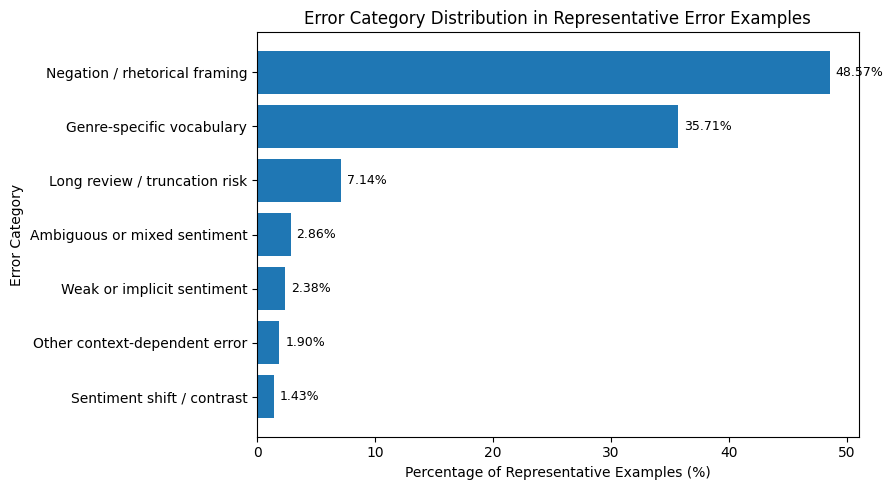

Saved: Error_category_summary_bar_chart.png


In [63]:
# Plot Error Category Summary
# Create summary table from representative examples

error_category_plot_df = (
    representative_error_examples_df["Error Category"]
    .value_counts()
    .reset_index()
)

error_category_plot_df.columns = [
    "Error Category",
    "Count"
]

total_representative_examples = len(representative_error_examples_df)

error_category_plot_df["Percentage"] = (
    error_category_plot_df["Count"]
    / total_representative_examples
    * 100
)

# Sort for horizontal bar chart
error_category_plot_df = error_category_plot_df.sort_values(
    by="Percentage",
    ascending=True
)

# Plot
plt.figure(figsize=(9, 5))

bars = plt.barh(
    error_category_plot_df["Error Category"],
    error_category_plot_df["Percentage"]
)

plt.xlabel("Percentage of Representative Examples (%)")
plt.ylabel("Error Category")
plt.title("Error Category Distribution in Representative Error Examples")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("Error_category_summary_bar_chart.png",dpi=300,bbox_inches="tight")
plt.show()
print("Saved: Error_category_summary_bar_chart.png")

In [64]:
# Check qualitative error analysis output files

important_qualitative_files = [
    "All_misclassified_reviews.csv",
    "Error_pattern_summary_misclassified.csv",
    "Representative_error_examples_by_pattern.csv",
    "Representative_error_examples_with_categories.csv",
    "Error_category_summary_table.csv",
    "Error_category_summary_bar_chart.png"
]

for file_name in important_qualitative_files:
    if os.path.exists(file_name):
        print(f"Found: {file_name}")
    else:
        print(f"Missing: {file_name}")

Found: All_misclassified_reviews.csv
Found: Error_pattern_summary_misclassified.csv
Found: Representative_error_examples_by_pattern.csv
Found: Representative_error_examples_with_categories.csv
Found: Error_category_summary_table.csv
Found: Error_category_summary_bar_chart.png


In [65]:
# Create enhanced final results table from 100% training data

enhanced_final_results_df = data_size_results_df[
    data_size_results_df["Training Data Ratio"] == "100%"
].copy()

enhanced_final_results_df = enhanced_final_results_df[[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Train Time (s)",
    "Inference Time (s)"
]]
enhanced_final_results_df = enhanced_final_results_df.reset_index(drop=True)

enhanced_final_results_df.to_csv("Enhanced_final_results_three_models.csv", index=False)
print("Saved: Enhanced_final_results_three_models.csv")

enhanced_final_results_df

Saved: Enhanced_final_results_three_models.csv


,Model,Accuracy,Precision,Recall,F1,Train Time (s),Inference Time (s)
0,TF-IDF + Naive Bayes,0.84984,0.864842,0.82928,0.846688,9.649062,4.096136
1,TF-IDF + Logistic Regression,0.88284,0.879952,0.88664,0.883284,10.305945,4.292568
2,DistilBERT,0.91372,0.906341,0.92280,0.914496,1810.676478,219.141574
